In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

# Norman 2019 — GI classification from raw expression

Scores genetic interactions directly from **observed expression**, with exactly the routine used for
SHERLOCK and GEARS in `norman_figure.ipynb` (Fig. 6d):

1. effect vectors = mean log2-CPM of each perturbation's cells minus the NTC mean (same formula as
   `get_gi(..., observed_singles='raw')`), on the same 3,270 filtered genes;
2. `regress_gi_params` — Theil–Sen regression of the double on its two singles, `min_cells=5`;
3. `classify_gi` — label-free equal-weight composite scores, argmax over classes;
4. `evaluate_gi_classification` — synergy subtypes merged, all labelled pairs (in distribution).

Raw expression is deterministic, so the five runs differ only in the Theil–Sen random seed
(1000–1004; 1000 is the seed the models use). SHERLOCK (observed mode) and GEARS per-run scores are
rebuilt from the cached `norman_figure` results. Output: one SVG in `results/module_interaction/`.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import sklearn.linear_model as sklm
from sklearn.metrics import f1_score, roc_auc_score, adjusted_rand_score, adjusted_mutual_info_score

import sherlock as slk
from sherlock.tools._models import regress_gi_params, classify_gi
warnings.filterwarnings('ignore')

mpl.rcParams.update({'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 9,
                     'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
                     'axes.spines.top': False, 'axes.spines.right': False, 'svg.fonttype': 'none'})

FIG_DIR = Path(f'{paths.RESULTS_DIR}/norman_figure')
SVG = Path(f'{paths.RESULTS_DIR}/module_interaction/supp_raw_expression_gi_per_class.svg')
SEEDS = [1000, 1001, 1002, 1003, 1004]
COLORS = {'Raw expression': '#4d4d4d', 'SHERLOCK': '#2166ac', 'GEARS': '#d73027'}

def canon_pair(s):
    s = str(s)
    if '+' not in s:
        return s
    a, b = s.split('+', 1)
    return '+'.join(sorted([a.strip(), b.strip()]))

## Data (same loading and gene filter as `norman_figure.ipynb`)

In [2]:
data = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(data, pert_key='perturbation_name', ntc_label='control',
                        treatment_key=None, inplace=True)
p_key, NTC = slk.configs.get_config('pert_key'), slk.configs.get_config('ntc_label')

all_perts = data.obs[p_key].unique()
pert_genes = {g.strip() for p in all_perts if p != NTC for g in str(p).split('+')}
mean_expr = np.asarray(data.X.mean(axis=0)).ravel()
data = data[:, (mean_expr > 0.5) | data.var_names.isin(pert_genes)].copy()

gi_labels = pd.read_csv(f'{paths.DATA_DIR}/norman/genetic_interactions.csv')
gi_labels['combination'] = gi_labels['combination'].map(canon_pair)
gi_labels['genetic_interaction'] = gi_labels['genetic_interaction'].str.strip()
gi_series = gi_labels.set_index('combination')['genetic_interaction']
print(f'{data.n_obs} cells, {data.n_vars} genes, {len(gi_labels)} labelled pairs')

111255 cells, 3270 genes, 88 labelled pairs


## Raw effect vectors (log2-CPM, perturbation mean minus NTC mean)

In [3]:
X = sp.csr_matrix(data.X, dtype=np.float64)
lib = np.asarray(X.sum(1)).ravel()
Xn = sp.diags(1e4 / np.maximum(lib, 1e-8)) @ X
Xn.data = np.log2(Xn.data + 1.0)                          # log2(1e4 * x / lib + 1), zeros stay zero

labels = data.obs[p_key].astype(str).map(canon_pair).values
uniq = pd.Index(sorted(set(labels)))
code_ = uniq.get_indexer(labels)
G = sp.csr_matrix((np.ones(len(labels)), (code_, np.arange(len(labels)))), shape=(len(uniq), len(labels)))
counts = np.asarray(G.sum(1)).ravel()
means = np.asarray((G @ Xn).todense()) / counts[:, None]

base = means[uniq.get_loc(str(NTC))]
effects = {u: means[i] - base for i, u in enumerate(uniq) if u != str(NTC)}
n_obs = {u: int(counts[i]) for i, u in enumerate(uniq) if u != str(NTC)}
combos = [c for c in effects if '+' in c and all(p in effects for p in c.split('+'))]
print(f'{len(effects) - len(combos)} singles, {len(combos)} combinations')

105 singles, 131 combinations


## Evaluation (copied from `norman_figure.ipynb`)

In [4]:
_SYN = {'synergy (similar phenotype)': 'synergy', 'synergy (dissimilar phenotype)': 'synergy'}
merge_syn = lambda s: s.astype(str).replace(_SYN)

def evaluate_gi_classification(df, model_name):
    work = df.copy()
    work.index = (work['pert_a'].astype(str) + '+' + work['pert_b'].astype(str)).map(canon_pair)
    work['gt_gi'] = work.index.map(gi_series)
    work = classify_gi(work, inplace=True)
    ev = work[work['gt_gi'].notna() & work['predicted_gi'].notna()]
    y_true, y_pred = merge_syn(ev['gt_gi']), merge_syn(ev['predicted_gi'])
    per_class = []
    for cls in sorted(set(y_true)):
        tb, pb = (y_true == cls).astype(int), (y_pred == cls).astype(int)
        per_class.append({'model': model_name, 'class': cls, 'n_positive': int(tb.sum()),
                          'f1': f1_score(tb, pb, zero_division=0),
                          'auc_roc': roc_auc_score(tb, pb) if 0 < tb.sum() < len(tb) else np.nan})
    summary = {'model': model_name, 'n_eval': len(ev),
               'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
               'ari': adjusted_rand_score(y_true, y_pred),
               'ami': adjusted_mutual_info_score(y_true, y_pred)}
    return pd.DataFrame(per_class), summary

## Five Theil–Sen regressions on raw expression

In [5]:
_TS = sklm.TheilSenRegressor
cls_rows, summ_rows = [], []
for run, seed in enumerate(SEEDS, 1):
    sklm.TheilSenRegressor = lambda *a, _s=seed, **k: _TS(*a, **{**k, 'random_state': _s})
    try:
        gi = regress_gi_params(effects, combos=combos, n_obs=n_obs, min_cells=5, progress=False)
    finally:
        sklm.TheilSenRegressor = _TS
    gi['gt_gi'] = gi.index.map(canon_pair).map(gi_series)
    gi = classify_gi(gi, fit_mask=gi.index.map(canon_pair).isin(set(gi_labels['combination'])), inplace=True)
    c, s = evaluate_gi_classification(gi, 'Raw expression')
    c['run'] = s['run'] = run
    cls_rows.append(c); summ_rows.append(s)
raw_cls, raw_summ = pd.concat(cls_rows), pd.DataFrame(summ_rows)
raw_summ.round(3)

,model,n_eval,f1_weighted,ari,ami,run
0,Raw expression,86,0.679,0.403,0.501,1
1,Raw expression,86,0.707,0.429,0.531,2
2,Raw expression,86,0.709,0.430,0.532,3
3,Raw expression,86,0.697,0.416,0.518,4
4,Raw expression,86,0.707,0.435,0.520,5


## SHERLOCK and GEARS per-run scores (cached `norman_figure` results)

In [6]:
slk_cls = pd.read_csv(FIG_DIR / 'gi_per_run_class_synmerged_observed.csv')
slk_summ = pd.read_csv(FIG_DIR / 'gi_per_run_summ_synmerged_observed.csv')
g_cls, g_summ = [], []
for run in range(1, 6):
    c, s = evaluate_gi_classification(pd.read_csv(FIG_DIR / 'gears_runs' / f'gears_gi_run{run}.csv'), 'GEARS')
    c['run'] = s['run'] = run
    g_cls.append(c); g_summ.append(s)

cls_all = pd.concat([raw_cls, slk_cls, *g_cls], ignore_index=True)
summ_all = pd.concat([raw_summ, slk_summ, pd.DataFrame(g_summ)], ignore_index=True)
overall = summ_all.groupby('model')[['f1_weighted', 'ari', 'ami', 'n_eval']].agg(['mean', 'std'])
overall = overall.loc[list(COLORS)]
print('Overall (mean ± SD over 5 runs, 86 labelled pairs, synergy merged):')
for m, r in overall.iterrows():
    print(f"  {m:15s} weighted F1 {r[('f1_weighted','mean')]:.3f} ± {r[('f1_weighted','std')]:.3f}   "
          f"ARI {r[('ari','mean')]:.3f} ± {r[('ari','std')]:.3f}   AMI {r[('ami','mean')]:.3f} ± {r[('ami','std')]:.3f}")
per_class = cls_all.groupby(['class', 'model'])[['f1', 'auc_roc']].agg(['mean', 'std']).round(3)
per_class

Overall (mean ± SD over 5 runs, 86 labelled pairs, synergy merged):
  Raw expression  weighted F1 0.700 ± 0.012   ARI 0.423 ± 0.013   AMI 0.521 ± 0.013
  SHERLOCK        weighted F1 0.712 ± 0.017   ARI 0.440 ± 0.016   AMI 0.512 ± 0.022
  GEARS           weighted F1 0.623 ± 0.035   ARI 0.387 ± 0.033   AMI 0.446 ± 0.050


f1        auc_roc       
                                        mean    std    mean    std
class                  model                                      
approximately additive GEARS           0.466  0.099   0.657  0.045
                       Raw expression  0.560  0.000   0.712  0.000
                       SHERLOCK        0.677  0.040   0.770  0.021
epistasis              GEARS           0.731  0.076   0.895  0.053
                       Raw expression  0.850  0.034   0.979  0.005
                       SHERLOCK        0.850  0.034   0.979  0.005
neomorphic             GEARS           0.452  0.073   0.708  0.055
                       Raw expression  0.800  0.026   0.859  0.018
                       SHERLOCK        0.667  0.063   0.767  0.028
potentiation           GEARS           0.708  0.056   0.868  0.044
                       Raw expression  0.520  0.018   0.800  0.003
                       SHERLOCK        0.581  0.035   0.810  0.005
redundant              GEARS           0.610  0.052   0.762  0.034
                       Raw expression  0.626  0.023   0.745  0.003
                       SHERLOCK        0.632  0.053   0.736  0.027
suppression            GEARS           0.585  0.052   0.713  0.022
                       Raw expression  0.766  0.075   0.815  0.040
                       SHERLOCK        0.747  0.057   0.860  0.038
synergy                GEARS           0.769  0.028   0.860  0.023
                       Raw expression  0.717  0.006   0.822  0.004
                       SHERLOCK        0.745  0.010   0.845  0.009

## Supplementary figure

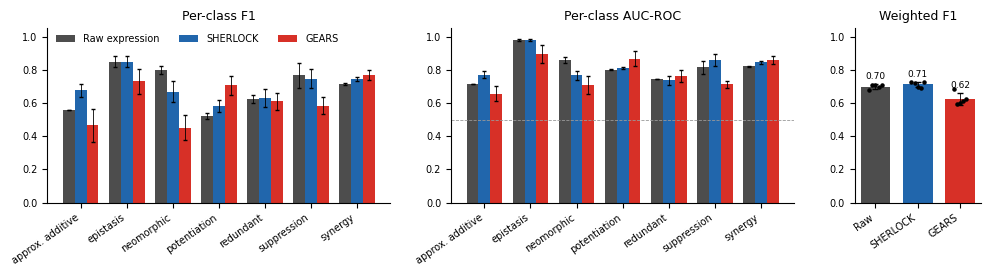

saved results/module_interaction/supp_raw_expression_gi_per_class.svg


In [7]:
classes = sorted(cls_all['class'].unique())
models = list(COLORS)
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), gridspec_kw={'width_ratios': [3, 3, 1.1]})
w = 0.26
for ax, metric, title in [(axes[0], 'f1', 'Per-class F1'), (axes[1], 'auc_roc', 'Per-class AUC-ROC')]:
    for j, m in enumerate(models):
        sub = cls_all[cls_all['model'] == m]
        mu = [sub.loc[sub['class'] == c, metric].mean() for c in classes]
        sd = [sub.loc[sub['class'] == c, metric].std() for c in classes]
        x = np.arange(len(classes)) + (j - 1) * w
        ax.bar(x, mu, w, yerr=sd, color=COLORS[m], label=m, capsize=1.5, error_kw={'lw': 0.6})
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels([c.replace('approximately ', 'approx. ') for c in classes], rotation=35, ha='right')
    ax.set_ylim(0, 1.05); ax.set_title(title)
axes[1].axhline(0.5, color='0.6', lw=0.6, ls='--')
axes[0].legend(frameon=False, loc='upper left', ncol=3, bbox_to_anchor=(0, 1.02))

ax = axes[2]
for j, m in enumerate(models):
    v = summ_all.loc[summ_all['model'] == m, 'f1_weighted']
    ax.bar(j, v.mean(), 0.7, yerr=v.std(), color=COLORS[m], capsize=2, error_kw={'lw': 0.6})
    ax.scatter(np.full(len(v), j) + np.linspace(-0.15, 0.15, len(v)), v, s=5, color='k', zorder=3)
    ax.text(j, v.mean() + v.std() + 0.03, f'{v.mean():.2f}', ha='center', fontsize=6.5)
ax.set_xticks(range(len(models))); ax.set_xticklabels(['Raw', 'SHERLOCK', 'GEARS'], rotation=35, ha='right')
ax.set_ylim(0, 1.05); ax.set_title('Weighted F1')
plt.tight_layout()
fig.savefig(SVG, bbox_inches='tight')
plt.show()
print('saved', SVG)